# 2. Data Understanding and Preprocessing

In this section, I analyse the structure and quality of the merged dataset. The aim is to understand the data distribution, identify missing values, and prepare the dataset for exploratory analysis and modelling.

Since the dataset contains hourly pollution and meteorological data from both urban and suburban stations, careful preprocessing is required before performing inference and predictive modelling.

In [28]:
import pandas as pd
import numpy as np

base_url = "https://raw.githubusercontent.com/Amjadkhan-CMU/Amjadkhan-CMU-CMP7005_PRAC1_AirQuality_Analysis-st20341331/main/data/processed/"

combined_df = pd.read_csv(base_url +"combined_air_quality_urban_suburban.csv")

combined_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan,2013-03-01 00:00:00
1,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong,2013-03-01 00:00:00
2,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi,2013-03-01 00:00:00
3,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
4,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong,2013-03-01 01:00:00


The dataset has been successfully loaded. Each row represents one hourly observation from one of the four selected monitoring stations.

The dataset includes pollutant concentrations such as PM2.5, PM10, NO2, SO2, CO, and O3, along with meteorological variables including temperature, pressure, dew point, wind speed, wind direction, and rainfall.

In [29]:
combined_df.shape
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   No        140256 non-null  int64  
 1   year      140256 non-null  int64  
 2   month     140256 non-null  int64  
 3   day       140256 non-null  int64  
 4   hour      140256 non-null  int64  
 5   PM2.5     137240 non-null  float64
 6   PM10      138128 non-null  float64
 7   SO2       137115 non-null  float64
 8   NO2       136211 non-null  float64
 9   CO        133563 non-null  float64
 10  O3        135969 non-null  float64
 11  TEMP      140113 non-null  float64
 12  PRES      140116 non-null  float64
 13  DEWP      140110 non-null  float64
 14  RAIN      140115 non-null  float64
 15  wd        139476 non-null  object 
 16  WSPM      140142 non-null  float64
 17  station   140256 non-null  object 
 18  datetime  140256 non-null  object 
dtypes: float64(11), int64(5), object(3)
memory u

The dataset contains a large number of hourly observations collected over four years. The variables are mostly numeric, which makes them suitable for statistical analysis and machine learning modelling.

The datetime column ensures the dataset can be analysed chronologically for time-series patterns such as hourly cycles and seasonal trends.

In [30]:
combined_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137240.000000,138128.000000,137115.000000,136211.000000,133563.000000,135969.000000,140113.000000,140116.000000,140110.000000,140115.000000,140142.000000
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,78.845636,100.947806,15.304842,46.362162,1198.388693,59.628428,13.632554,1011.220695,2.281518,0.062451,1.816861
std,10122.141,1.177201,3.448715,8.800123,6.922211,81.994805,91.365099,21.328641,34.799286,1155.531881,56.322936,11.424057,10.517577,13.773501,0.774665,1.272493
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.800000,982.400000,-36.000000,0.000000,0.000000
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,19.000000,400.000000,13.000000,3.200000,1002.700000,-9.100000,0.000000,1.000000
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,53.000000,78.000000,7.000000,38.000000,800.000000,49.000000,14.600000,1010.900000,2.800000,0.000000,1.500000
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,110.000000,140.000000,19.000000,66.619850,1500.000000,84.000000,23.400000,1019.500000,14.900000,0.000000,2.300000
max,35064.000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,411.000000,273.000000,10000.000000,500.000000,41.400000,1042.800000,28.800000,52.100000,13.200000


The statistical summary shows significant variation in pollutant concentrations.

For example, PM2.5 and PM10 show high maximum values, indicating the presence of severe pollution episodes during the study period. The large standard deviation values suggest considerable fluctuation in air quality over time.

In [31]:
missing_values = combined_df.isnull().sum()
missing_percentage = (missing_values / len(combined_df)) * 100

pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
}).sort_values("Missing Percentage (%)", ascending=False)

,Missing Values,Missing Percentage (%)
CO,6693,4.771988
O3,4287,3.056554
NO2,4045,2.884012
SO2,3141,2.239476
PM2.5,3016,2.150354
PM10,2128,1.517226
wd,780,0.556126
DEWP,146,0.104095
TEMP,143,0.101956
RAIN,141,0.100530


The missing value analysis reveals that certain pollutant measurements contain incomplete records. This is common in environmental monitoring due to sensor maintenance or temporary equipment failure.

Before proceeding to modelling, appropriate strategies such as removing or imputing missing values must be considered to ensure reliable results.

In [32]:
combined_df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [33]:
combined_df["datetime"] = pd.to_datetime(combined_df["datetime"])

In [34]:
combined_df["datetime"].dtype

dtype('<M8[ns]')

The datetime column was converted to a proper datetime format to ensure compatibility with time-series operations such as grouping by hour, month, and season. This step is essential for conducting accurate temporal analysis.

In [35]:
combined_df["area_type"] = combined_df["station"].apply(
    lambda x: "Urban" if x in ["Nongzhanguan", "Wanshouxigong"] else "Suburban"
)

combined_df[["station", "area_type"]].drop_duplicates()

,station,area_type
0,Nongzhanguan,Urban
1,Wanshouxigong,Urban
2,Shunyi,Suburban
3,Dingling,Suburban


To compare pollution patterns between urban and suburban environments, I categorised the stations into two area types. Nongzhanguan and Wanshouxigong represent urban locations, while Shunyi and Dingling represent suburban areas.

This classification allows a structured comparison of pollution behaviour across different spatial settings.

In [36]:
urban_suburban_mean = combined_df.groupby("area_type")["PM2.5"].mean()

urban_suburban_mean

,PM2.5
area_type,
Suburban,72.727331
Urban,84.931218


The average PM2.5 concentration in urban stations (84.93 µg/m³) is noticeably higher than in suburban stations (72.73 µg/m³).

This difference suggests that urban environments experience greater particulate pollution, likely due to higher traffic density, industrial activity, and population concentration. In contrast, suburban stations show relatively lower average concentrations, possibly due to reduced emission sources and better natural dispersion.

This initial comparison confirms a clear spatial difference in air quality between inner-city and outer-city areas.

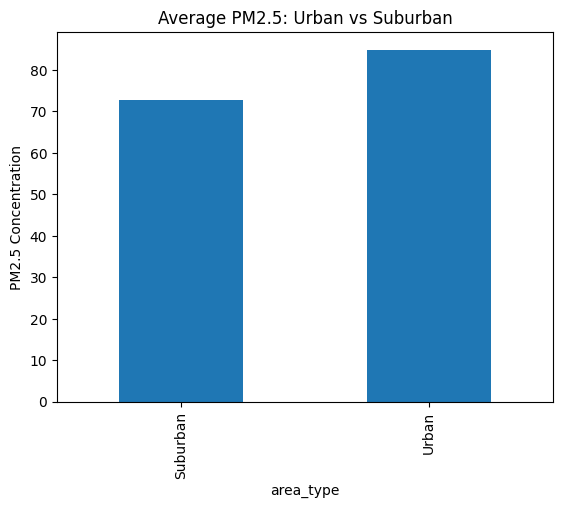

In [37]:
import matplotlib.pyplot as plt

urban_suburban_mean.plot(kind="bar")
plt.title("Average PM2.5: Urban vs Suburban")
plt.ylabel("PM2.5 Concentration")
plt.show()

The bar chart clearly illustrates the difference in average PM2.5 levels between urban and suburban stations. The higher urban concentration supports the hypothesis that city environments are more prone to particulate pollution accumulation.

In [38]:
combined_df.groupby("area_type")["PM2.5"].agg(["mean", "std", "max", "min"])

,mean,std,max,min
area_type,,,,
Suburban,72.727331,77.167048,941.0,2.0
Urban,84.931218,86.100300,999.0,2.0


The comparison shows that urban stations have both higher average PM2.5 levels (84.93 µg/m³) and higher variability (standard deviation = 86.10) compared to suburban stations (mean = 72.73 µg/m³, standard deviation = 77.17).

In addition, the maximum recorded PM2.5 concentration is higher in urban areas (999 µg/m³) than in suburban areas (941 µg/m³), indicating more extreme pollution episodes within the city environment.

These results suggest that urban locations not only experience higher overall pollution but also greater fluctuation and intensity of particulate matter events, likely influenced by dense traffic, industrial emissions, and limited airflow due to built infrastructure.

In [39]:
hourly_pm25 = combined_df.groupby(["area_type", "hour"])["PM2.5"].mean().reset_index()

hourly_pm25.head()

,area_type,hour,PM2.5
0,Suburban,0,80.069158
1,Suburban,1,78.541166
2,Suburban,2,75.733391
3,Suburban,3,72.229331
4,Suburban,4,69.631691


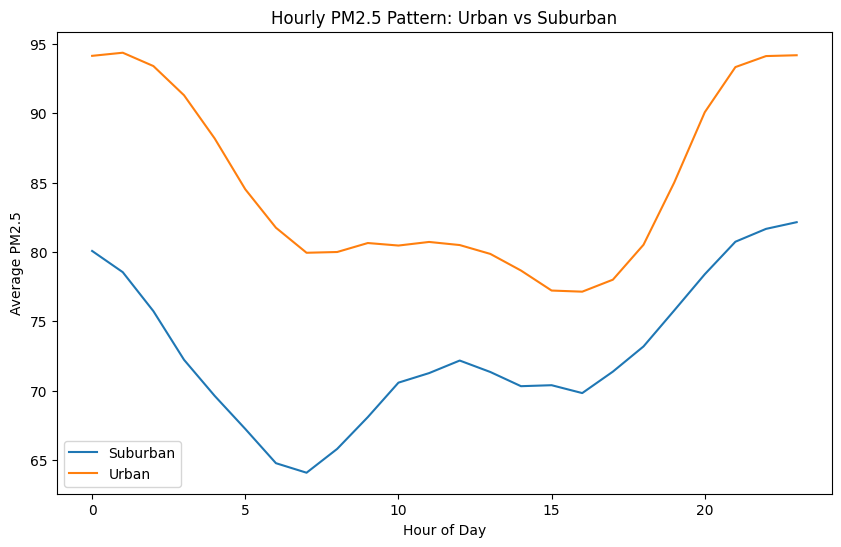

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for area in hourly_pm25["area_type"].unique():
    subset = hourly_pm25[hourly_pm25["area_type"] == area]
    plt.plot(subset["hour"], subset["PM2.5"], label=area)

plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5")
plt.title("Hourly PM2.5 Pattern: Urban vs Suburban")
plt.legend()
plt.show()

### Hourly Pollution Pattern Analysis

The hourly PM2.5 pattern reveals a clear diurnal cycle in both urban and suburban areas.

Urban stations show elevated concentrations during late night and early morning hours (00:00–02:00), followed by a gradual decrease toward midday. The lowest urban concentrations occur around 15:00–16:00, likely due to increased atmospheric mixing and stronger wind-driven dispersion during daytime.

Suburban stations follow a similar pattern but with consistently lower concentration levels. The suburban minimum occurs earlier in the morning (around 06:00–07:00), after which pollution gradually increases toward the evening.

The consistent difference between urban and suburban curves across all hours indicates sustained higher emission intensity within city areas. The late-night peaks may reflect accumulated pollutants under stable atmospheric conditions with reduced vertical air mixing.

In [41]:
hourly_pm25.sort_values("PM2.5", ascending=False).head()

,area_type,hour,PM2.5
25,Urban,1,94.349098
47,Urban,23,94.167765
24,Urban,0,94.124306
46,Urban,22,94.108052
26,Urban,2,93.388199


Further examination of the hourly averages shows that the highest PM2.5 concentrations occur between 22:00 and 02:00 in urban stations, with a peak at 01:00 (94.35 µg/m³).

This pattern suggests that particulate matter accumulates during late-night and early-morning hours. One possible explanation is reduced atmospheric mixing during nighttime, when temperature inversion layers can trap pollutants close to the ground. In urban environments, continuous emission sources such as traffic, heating systems, and industrial activity may contribute to sustained pollutant accumulation.

The absence of similar peak magnitudes in suburban stations further highlights the stronger influence of concentrated emission sources within urban areas.

This finding indicates that not only daytime human activity but also nighttime atmospheric conditions significantly affect urban air quality.